“We are installing PySpark library so that we can use Apache Spark in Google Colab.”
!pip install pyspark
– Create Spark Session
because SparkSession is entry point of Spark.

It starts Spark engine.

Without SparkSession, Spark cannot run.

Analogy:
SparkSession is like turning on the engine of a car


In [ ]:

#STEP 1 – Start Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Movie Recommendation Project") \
    .getOrCreate()

#STEP 2 – Upload Dataset in Colab
Upload:

ratings.csv

movies.csv
# EXplanation

spark.read.csv → loads file

header=True → first row is column names

inferSchema=True → automatically detect data types

Explain:

DataFrame is like a table in SQL.

In [ ]:
#STEP 2 – Load Dataset
ratings = spark.read.csv("/content/rating.csv", header=True, inferSchema=True)
movies = spark.read.csv("/content/movie.csv", header=True, inferSchema=True)

ratings.show(5)
movies.show(5)

+------+-------+------+-------------------+
|userId|movieId|rating|          timestamp|
+------+-------+------+-------------------+
|     1|      2|   3.5|2005-04-02 23:53:47|
|     1|     29|   3.5|2005-04-02 23:31:16|
|     1|     32|   3.5|2005-04-02 23:33:39|
|     1|     47|   3.5|2005-04-02 23:32:07|
|     1|     50|   3.5|2005-04-02 23:29:40|
+------+-------+------+-------------------+
only showing top 5 rows
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows


# Explain:

Why join?

Because:
ratings has rating
movies has title

We join to get:
userId | title | rating | genres

Analogy:

Joining two tables is like combining two sheets in Excel using common column.



In [ ]:
#STEP 3 – Join Both Tables
df = ratings.join(movies, on="movieId")

df.show(5)

+-------+------+------+-------------------+--------------------+--------------------+
|movieId|userId|rating|          timestamp|               title|              genres|
+-------+------+------+-------------------+--------------------+--------------------+
|      2|     1|   3.5|2005-04-02 23:53:47|      Jumanji (1995)|Adventure|Childre...|
|     29|     1|   3.5|2005-04-02 23:31:16|City of Lost Chil...|Adventure|Drama|F...|
|     32|     1|   3.5|2005-04-02 23:33:39|Twelve Monkeys (a...|Mystery|Sci-Fi|Th...|
|     47|     1|   3.5|2005-04-02 23:32:07|Seven (a.k.a. Se7...|    Mystery|Thriller|
|     50|     1|   3.5|2005-04-02 23:29:40|Usual Suspects, T...|Crime|Mystery|Thr...|
+-------+------+------+-------------------+--------------------+--------------------+
only showing top 5 rows












# Explain Line-by-Line:

groupBy("title") → group data by movie

---


avg("rating") → calculate average
count("rating") → total ratings
filter > 50 → remove movies with few ratings
orderBy → highest first

Important point:

A movie rated by only 1 user is not reliable.

In [ ]:
#STEP 4 –Top Rated Movies
from pyspark.sql.functions import avg, count

top_rated = df.groupBy("title") \
    .agg(avg("rating").alias("avg_rating"),
         count("rating").alias("total_ratings")) \
    .filter("total_ratings > 50") \
    .orderBy("avg_rating", ascending=False)

top_rated.show(10)

+--------------------+------------------+-------------+
|               title|        avg_rating|total_ratings|
+--------------------+------------------+-------------+
|Shawshank Redempt...| 4.461363165527243|         4827|
|Godfather, The (1...| 4.385185185185185|         3240|
|Usual Suspects, T...|4.3667668761956815|         3659|
|Band of Brothers ...| 4.323099415204679|          342|
|Schindler's List ...| 4.307879876796714|         3896|
|Godfather: Part I...|  4.29696132596685|         2172|
|Creature Comforts...| 4.286082474226804|          194|
|   Casablanca (1942)|4.2804752066115705|         1936|
|World of Apu, The...| 4.269230769230769|           52|
|Passion of Joan o...| 4.268518518518518|           54|
+--------------------+------------------+-------------+
only showing top 10 rows


# Here we are not checking rating value.

We are checking:
Which movie has most number of ratings?

More ratings = More popularity

In [ ]:
#STEP 5 – Most Popular Movies

popular_movies = df.groupBy("title") \
    .agg(count("rating").alias("rating_count")) \
    .orderBy("rating_count", ascending=False)

popular_movies.show(10)





+--------------------+------------+
|               title|rating_count|
+--------------------+------------+
| Pulp Fiction (1994)|        5228|
| Forrest Gump (1994)|        5214|
|Silence of the La...|        4876|
|Shawshank Redempt...|        4827|
|Jurassic Park (1993)|        4670|
|Star Wars: Episod...|        4322|
|   Braveheart (1995)|        4187|
|Terminator 2: Jud...|        4124|
|  Matrix, The (1999)|        4033|
|Schindler's List ...|        3896|
+--------------------+------------+
only showing top 10 rows


In [ ]:
#STEP 6 – Most Active Users
active_users = df.groupBy("userId") \
    .agg(count("movieId").alias("movies_rated")) \
    .orderBy("movies_rated", ascending=False)

active_users.show(10)


+------+------------+
|userId|movies_rated|
+------+------------+
|  8405|        7515|
|  8963|        4524|
|  9544|        3804|
|  7201|        3014|
|  3907|        2711|
|  2261|        2644|
|   903|        2608|
|  4358|        2575|
|  4222|        2553|
|  9034|        2448|
+------+------------+
only showing top 10 rows


In [ ]:
#STEP 7 – Genre Wise Analysis
from pyspark.sql.functions import split, explode

genre_df = df.withColumn("genre", explode(split(df.genres, "\\|")))

genre_rating = genre_df.groupBy("genre") \
    .agg(avg("rating").alias("avg_rating")) \
    .orderBy("avg_rating", ascending=False)

genre_rating.show()

+------------------+------------------+
|             genre|        avg_rating|
+------------------+------------------+
|         Film-Noir| 3.952675379476059|
|               War|3.8155402365928683|
|       Documentary| 3.733638016361984|
|             Crime| 3.679428967515323|
|             Drama|3.6714612926570647|
|           Mystery| 3.661105764525495|
|              IMAX|  3.65346112886049|
|         Animation| 3.607828110808356|
|           Western| 3.564283172192894|
|           Musical|3.5459400156935685|
|           Romance| 3.538080997835986|
|          Thriller| 3.505093795854952|
|         Adventure| 3.502362870669887|
|           Fantasy| 3.500544402034854|
|            Action| 3.445318881236619|
|            Sci-Fi|3.4308623516928716|
|            Comedy| 3.425349441584012|
|          Children| 3.397042019126794|
|            Horror|3.2579029017573307|
|(no genres listed)|               3.1|
+------------------+------------------+



In [ ]:
#STEP 8 – Basic Recommendation Logic
#Find users who liked a specific movie (rating >= 4)
liked_movie = df.filter((df.title == "Toy Story (1995)") & (df.rating >= 4))

liked_movie.show()

+-------+------+------+-------------------+----------------+--------------------+
|movieId|userId|rating|          timestamp|           title|              genres|
+-------+------+------+-------------------+----------------+--------------------+
|      1|     3|   4.0|1999-12-11 13:36:47|Toy Story (1995)|Adventure|Animati...|
|      1|     6|   5.0|1997-03-13 17:50:52|Toy Story (1995)|Adventure|Animati...|
|      1|     8|   4.0|1996-06-05 13:37:51|Toy Story (1995)|Adventure|Animati...|
|      1|    10|   4.0|1999-11-25 02:44:47|Toy Story (1995)|Adventure|Animati...|
|      1|    11|   4.5|2009-01-02 01:13:41|Toy Story (1995)|Adventure|Animati...|
|      1|    12|   4.0|1997-03-22 20:48:38|Toy Story (1995)|Adventure|Animati...|
|      1|    13|   4.0|1996-11-27 08:21:31|Toy Story (1995)|Adventure|Animati...|
|      1|    14|   4.5|2008-10-29 20:13:59|Toy Story (1995)|Adventure|Animati...|
|      1|    19|   5.0|1997-02-05 21:03:48|Toy Story (1995)|Adventure|Animati...|
|      1|    23|

In [ ]:
#Now find what else those users liked:
users = liked_movie.select("userId")

recommendations = df.join(users, "userId") \
    .groupBy("title") \
    .agg(avg("rating").alias("avg_rating")) \
    .orderBy("avg_rating", ascending=False)

recommendations.show(10)

+--------------------+----------+
|               title|avg_rating|
+--------------------+----------+
|Dragon Ball Z: De...|       5.0|
|  Movie Movie (1978)|       5.0|
|Storefront Hitchc...|       5.0|
|Diana Vreeland: T...|       5.0|
|   Still Bill (2009)|       5.0|
|Night Crossing (1...|       5.0|
| Street Thief (2006)|       5.0|
|  Tunnel, The (2011)|       5.0|
|Brand Upon the Br...|       5.0|
|Perfect Game, The...|       5.0|
+--------------------+----------+
only showing top 10 rows


🚀 ADVANCED VERSION WITH VISUALIZATIONS

In [ ]:
top_rated_pd = top_rated.limit(10).toPandas()

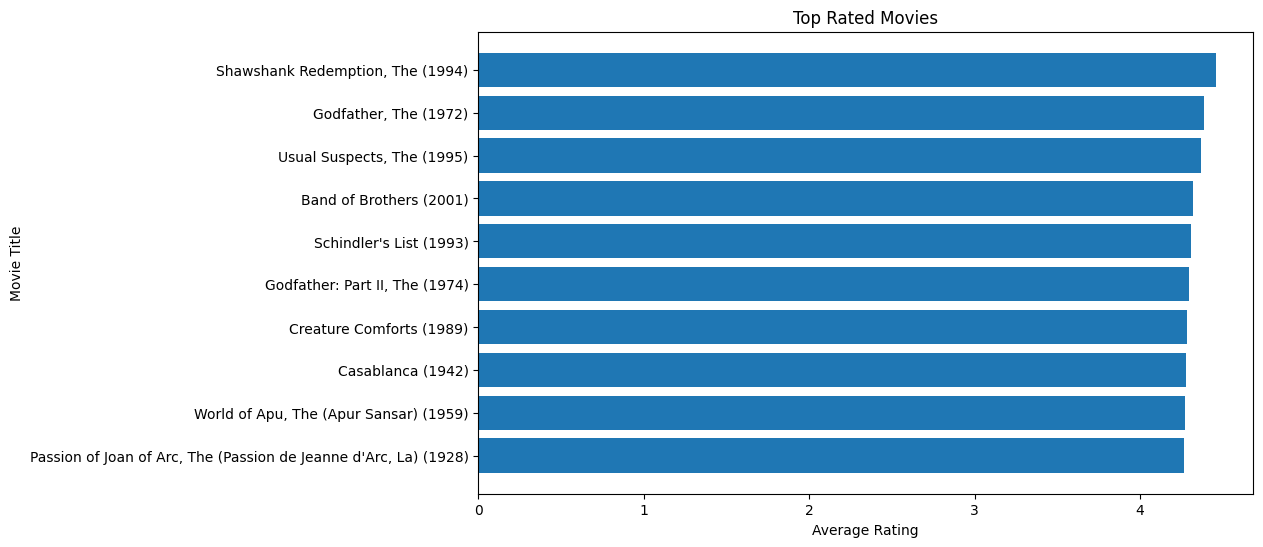

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_rated_pd['title'], top_rated_pd['avg_rating'])
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.title("Top Rated Movies")
plt.gca().invert_yaxis()
plt.show()